# **Chapter: 07  Ensemble Learning**


In [1]:
!pip install deslib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.6/172.6 kB 6.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.datasets import load_digits

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import validation_curve
from deslib.des.knora_e import KNORAE


from sklearn.metrics import accuracy_score, mean_squared_error, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report



## Stacking Models using DESLIB

# # Train a pool of 10 classifiers
# pool_classifiers = RandomForestClassifier(n_estimators=10)
# pool_classifiers.fit(X_train, y_train)

# # Initialize the DES model
# knorae = KNORAE(pool_classifiers)

# # Preprocess the Dynamic Selection dataset (DSEL)
# knorae.fit(X_dsel, y_dsel)

# # Predict new examples:
# knorae.predict(X_test)



8. Load the MNIST data (introduced in Chapter 3), and split it into a training set, a validation set, and a test set (e.g., use the first 40,000 instances for training, the next 10,000 for validation, and the last 10,000 for testing). Then train various classifiers, such as a Random Forest classifier, an Extra-Trees classifier, and an SVM. Next, try to combine them into an ensemble that outperforms them all on the validation set, using a soft or hard voting classifier. Once you have found one, try it on the test set. How much better does it perform compared to the individual classifiers?



In [ ]:
X, y = fetch_openml('mnist_784', version=1,
                    return_X_y=True, as_frame=False,
                    parser='pandas'
)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# **Logistic Reg:**

In [6]:
lr = LogisticRegression(solver='saga',max_iter=10000, random_state=42)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000, random_state=42, solver='saga')

In [7]:
y_val_pred = lr.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", val_accuracy)
print(classification_report(y_val, y_val_pred))


Validation Accuracy: 0.9149107142857142
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1126
           1       0.95      0.98      0.96      1274
           2       0.93      0.88      0.90      1106
           3       0.89      0.90      0.89      1144
           4       0.92      0.93      0.93      1104
           5       0.87      0.87      0.87      1039
           6       0.94      0.94      0.94      1096
           7       0.93      0.93      0.93      1149
           8       0.88      0.86      0.87      1090
           9       0.89      0.90      0.90      1072

    accuracy                           0.91     11200
   macro avg       0.91      0.91      0.91     11200
weighted avg       0.91      0.91      0.91     11200



In [8]:
y_test_pred = lr.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_accuracy)

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.9150714285714285
Test Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1343
           1       0.94      0.97      0.96      1600
           2       0.91      0.89      0.90      1380
           3       0.90      0.89      0.89      1433
           4       0.93      0.92      0.92      1295
           5       0.88      0.87      0.88      1273
           6       0.94      0.95      0.94      1396
           7       0.92      0.94      0.93      1503
           8       0.90      0.85      0.88      1357
           9       0.89      0.90      0.89      1420

    accuracy                           0.92     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.91      0.92      0.91     14000



# **SVM Classification:**

In [9]:
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42,
              cache_size=200)

svm_clf.fit(X_train_scaled, y_train)


SVC(random_state=42)

In [10]:
y_val_pred = svm_clf.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", val_accuracy)
print(classification_report(y_val, y_val_pred))


Validation Accuracy: 0.9646428571428571
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1126
           1       0.98      0.99      0.98      1274
           2       0.95      0.96      0.96      1106
           3       0.96      0.95      0.96      1144
           4       0.97      0.97      0.97      1104
           5       0.98      0.95      0.96      1039
           6       0.97      0.97      0.97      1096
           7       0.92      0.97      0.95      1149
           8       0.97      0.96      0.96      1090
           9       0.97      0.93      0.95      1072

    accuracy                           0.96     11200
   macro avg       0.96      0.96      0.96     11200
weighted avg       0.96      0.96      0.96     11200



In [11]:
y_test_pred = svm_clf.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_accuracy)

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.9611428571428572
Test Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1343
           1       0.98      0.99      0.98      1600
           2       0.96      0.96      0.96      1380
           3       0.96      0.95      0.96      1433
           4       0.96      0.96      0.96      1295
           5       0.96      0.95      0.96      1273
           6       0.97      0.98      0.97      1396
           7       0.92      0.97      0.94      1503
           8       0.97      0.95      0.96      1357
           9       0.96      0.93      0.94      1420

    accuracy                           0.96     14000
   macro avg       0.96      0.96      0.96     14000
weighted avg       0.96      0.96      0.96     14000



# **Extra-Trees classifier:**

In [12]:
extratree_clf = ExtraTreesClassifier(
    n_estimators=100, max_depth=None,
    criterion='gini', random_state=42,
    n_jobs=-1
)

extratree_clf.fit(X_train, y_train)

ExtraTreesClassifier(n_jobs=-1, random_state=42)

In [13]:
y_val_pred = extratree_clf.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", val_accuracy)
print(classification_report(y_val, y_val_pred))


Validation Accuracy: 0.9716071428571429
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1126
           1       0.99      0.99      0.99      1274
           2       0.97      0.97      0.97      1106
           3       0.96      0.97      0.96      1144
           4       0.98      0.97      0.98      1104
           5       0.98      0.97      0.97      1039
           6       0.98      0.97      0.97      1096
           7       0.98      0.97      0.98      1149
           8       0.96      0.96      0.96      1090
           9       0.95      0.95      0.95      1072

    accuracy                           0.97     11200
   macro avg       0.97      0.97      0.97     11200
weighted avg       0.97      0.97      0.97     11200



In [14]:
y_test_pred = extratree_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_accuracy)

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.9678571428571429
Test Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1343
           1       0.98      0.98      0.98      1600
           2       0.96      0.97      0.96      1380
           3       0.96      0.95      0.96      1433
           4       0.97      0.96      0.96      1295
           5       0.97      0.96      0.97      1273
           6       0.98      0.99      0.98      1396
           7       0.97      0.97      0.97      1503
           8       0.96      0.96      0.96      1357
           9       0.95      0.95      0.95      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



## **Feature Importance:**

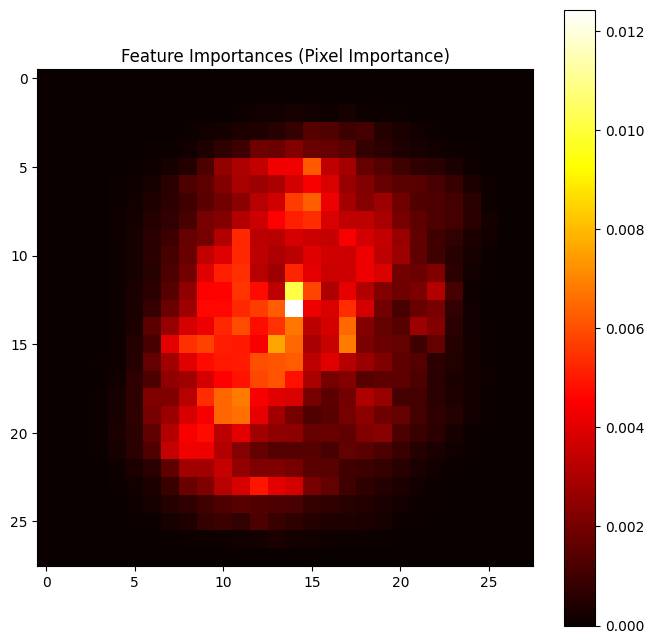

In [15]:
importances = extratree_clf.feature_importances_
importances_image = importances.reshape(28, 28)

plt.figure(figsize=(8, 8))
plt.imshow(importances_image, cmap='hot')
plt.title('Feature Importances (Pixel Importance)')
plt.colorbar()
plt.show()

# **Random Forest**

In [16]:
rf_clf = RandomForestClassifier(
    n_estimators=300, max_depth=None, criterion='gini', min_samples_split=2,min_samples_leaf=1, bootstrap=True, random_state=42,n_jobs=-1
)

rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [17]:
y_val_pred = rf_clf.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", val_accuracy)
print(classification_report(y_val, y_val_pred))


Validation Accuracy: 0.9671428571428572
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1126
           1       0.99      0.99      0.99      1274
           2       0.97      0.96      0.96      1106
           3       0.96      0.96      0.96      1144
           4       0.97      0.97      0.97      1104
           5       0.97      0.96      0.97      1039
           6       0.97      0.97      0.97      1096
           7       0.97      0.97      0.97      1149
           8       0.96      0.95      0.96      1090
           9       0.94      0.94      0.94      1072

    accuracy                           0.97     11200
   macro avg       0.97      0.97      0.97     11200
weighted avg       0.97      0.97      0.97     11200



In [18]:
y_test_pred = rf_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_accuracy)

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.9659285714285715
Test Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1343
           1       0.98      0.99      0.98      1600
           2       0.95      0.97      0.96      1380
           3       0.96      0.95      0.95      1433
           4       0.97      0.97      0.97      1295
           5       0.97      0.96      0.97      1273
           6       0.98      0.98      0.98      1396
           7       0.97      0.96      0.97      1503
           8       0.95      0.95      0.95      1357
           9       0.95      0.95      0.95      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



# **Voting Classifier:**

In [19]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", lr)
])

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", svm_clf)
])

voting_clf = VotingClassifier(
    estimators=[("lr", lr_pipe), ("svm", svm_pipe), ("extra-tree", extratree_clf), ("rf_clf", rf_clf)], voting='hard'
)

In [20]:
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('lr',
                                               LogisticRegression(max_iter=10000,
                                                                  random_state=42,
                                                                  solver='saga'))])),
                             ('svm',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('svm', SVC(random_state=42))])),
                             ('extra-tree',
                              ExtraTreesClassifier(n_jobs=-1, random_state=42)),
                             ('rf_clf',
                              RandomForestClassifier(n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42))])

### **Including the Voting Classifier along with other classifiers:**

In [21]:
print(voting_clf.estimators_[1])

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(random_state=42))])


In [22]:
for clf in (lr, svm_clf, extratree_clf, rf_clf, voting_clf):
  if clf == svm_clf:
    y_pred = clf.predict(X_test_scaled)
  else:
    y_pred = clf.predict(X_test)

    print(f"\n{'='*60}")
    print(f"Model: {clf.__class__.__name__}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Model: LogisticRegression
Accuracy: 0.8194

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1343
           1       0.97      0.78      0.87      1600
           2       0.93      0.76      0.84      1380
           3       0.86      0.88      0.87      1433
           4       0.89      0.88      0.89      1295
           5       0.98      0.24      0.39      1273
           6       0.92      0.93      0.93      1396
           7       0.97      0.84      0.90      1503
           8       0.47      0.96      0.63      1357
           9       0.80      0.91      0.85      1420

    accuracy                           0.82     14000
   macro avg       0.87      0.82      0.81     14000
weighted avg       0.87      0.82      0.82     14000


Model: ExtraTreesClassifier
Accuracy: 0.9679

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     

# **Stacking Techinque by using Stacking Classifiers:**

In [23]:
!pip install deslib

In [24]:
# from deslib.des.knora_e import KNORAE

# for clf in (lr, svm_clf, extratree_clf, rf_clf, voting_clf, ada_svm_clf, ada_clf, gbrt_best):
#   knorae = KNORAE(clf)


# knorae.fit(X_val, y_val)

# y_pred = knorae.predict(X_test)

## it will take alot of time so i m going to use the stacking manually

# estimators = [
#     ('lr', lr),
#     ('svm', svm_clf),
#     ('et', extratree_clf),
#     ('rf', rf_clf),
#     ('voting', voting_clf),
#     ('ada_svm', ada_svm_clf),
#     ('ada', ada_clf),
#     ('gbrt', gbrt_best)
# ]

# stacking_clf = StackingClassifier(
#     estimators=estimators,
#     final_estimator=LogisticRegression(),
#     cv=5
# )

# stacking_clf.fit(X_train, y_train)


# **Manual Stacking Due to High Time of training:**

In [25]:
pred_lr = lr.predict(X_val_scaled)
pred_svm = svm_clf.predict(X_val_scaled)
pred_et = extratree_clf.predict(X_val)
pred_rf = rf_clf.predict(X_val)
pred_voting = voting_clf.predict(X_val)


meta_X_val = np.column_stack([
    pred_lr,
    pred_svm,
    pred_et,
    pred_rf,
    pred_voting
])


In [26]:
meta_model = LogisticRegression(random_state=42)
meta_model.fit(meta_X_val, y_val)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [27]:
test_lr = lr.predict(X_test_scaled)
test_svm = svm_clf.predict(X_test_scaled)
test_et = extratree_clf.predict(X_test)
test_rf = rf_clf.predict(X_test)
test_voting = voting_clf.predict(X_test)

meta_X_test = np.column_stack([
    test_lr,
    test_svm,
    test_et,
    test_rf,
    test_voting
])

In [28]:
final_pred = meta_model.predict(meta_X_test)

In [29]:
models = {
    "Logistic Regression": test_lr,
    "SVM": test_svm,
    "Extra Trees": test_et,
    "Random Forest": test_rf,
    "Voting Classifier": test_voting,
    "Stacking Classifier": final_pred
}

for name, pred in models.items():
    acc = accuracy_score(y_test, pred)
    print(f"{name:<25}: ", acc)
    

Logistic Regression      :  0.9150714285714285
SVM                      :  0.9611428571428572
Extra Trees              :  0.9678571428571429
Random Forest            :  0.9659285714285715
Voting Classifier        :  0.9676428571428571
Stacking Classifier      :  0.9418571428571428


In [30]:
stack_acc = accuracy_score(y_test, final_pred)

print("Stacking Accuracy: ", stack_acc)

print("Classification Report: ")
print(classification_report(y_test, final_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, final_pred))

Stacking Accuracy:  0.9418571428571428
Classification Report: 
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1343
           1       0.98      0.97      0.98      1600
           2       0.94      0.95      0.94      1380
           3       0.91      0.93      0.92      1433
           4       0.90      0.90      0.90      1295
           5       0.94      0.91      0.92      1273
           6       0.96      0.97      0.96      1396
           7       0.95      0.94      0.95      1503
           8       0.90      0.94      0.92      1357
           9       0.96      0.93      0.94      1420

    accuracy                           0.94     14000
   macro avg       0.94      0.94      0.94     14000
weighted avg       0.94      0.94      0.94     14000

Confusion Matrix:
[[1306    4   18    4    3    2    1    0    5    0]
 [  11 1558   16    5    2    0    0    4    3    1]
 [   2   11 1309   22   20    2    2    2    9    1]
 

In [31]:
 feature_names = [
    "Logistic Regression",
    "SVM",
    "Extra Trees",
    "Random Forest",
    "Voting"
]

for name, coef in zip(feature_names, meta_model.coef_[0]):
    print(f"{name:<25}: {coef:.4f}")


Logistic Regression      : 2.8379
SVM                      : -6.3859
Extra Trees              : -7.1852
Random Forest            : -6.6519
Voting                   : -8.3439


In [32]:
best_base_acc = max(
    accuracy_score(y_test, test_lr),
    accuracy_score(y_test, test_svm),
    accuracy_score(y_test, test_et),
    accuracy_score(y_test, test_rf),
    accuracy_score(y_test, test_voting)
)

In [33]:
if stack_acc > best_base_acc:
    print("Stacking improved over all base models.")
elif stack_acc == best_base_acc:
    print("Stacking matched the best base model.")
else:
    print("Stacking performed worse than the best base model.")

Stacking performed worse than the best base model.
